In [216]:
import pandas as pd
import numpy as np

In [217]:
file = "C:/Users/rios9/OneDrive/Documents/Data Science/Portfolio/Data Science/DataCoSupplyChainDataset.csv"
df = pd.read_csv(file, encoding="latin1")

In [218]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [219]:
df.shape

(180519, 53)

In [220]:
pd.isnull(df).sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [221]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [222]:
from datetime import datetime

df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

In [223]:
df = df.drop(columns=['Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 'Customer Street', 'Product Description', 'Order Zipcode', 'Product Image'])

In [224]:
df.value_counts(df['Late_delivery_risk'], normalize=True)*100

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

<Axes: xlabel='Late_delivery_risk', ylabel='count'>

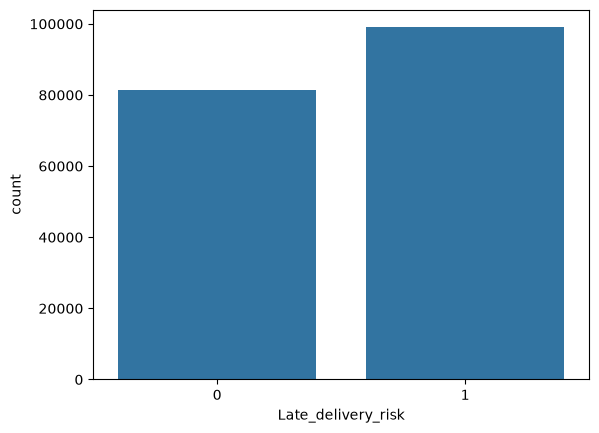

In [225]:
import seaborn as sns

sns.countplot(x='Late_delivery_risk', data=df)

In [226]:
df.groupby('Shipping Mode')['Late_delivery_risk'].mean()

Shipping Mode
First Class       0.953225
Same Day          0.457430
Second Class      0.766328
Standard Class    0.380717
Name: Late_delivery_risk, dtype: float64

<Axes: xlabel='Shipping Mode', ylabel='Late_delivery_risk'>

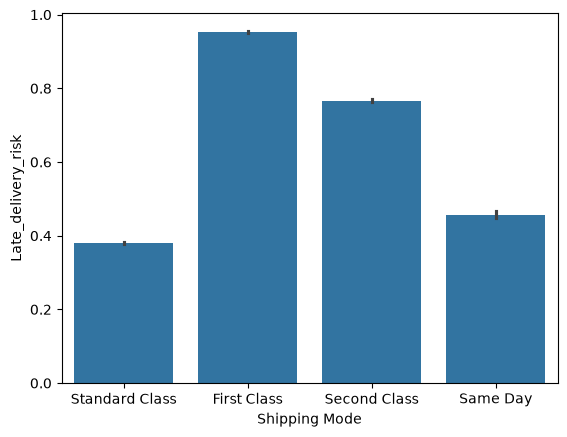

In [227]:
sns.barplot(x='Shipping Mode', y='Late_delivery_risk', data=df)

In [228]:
df = df.drop(columns=['shipping date (DateOrders)'])

In [229]:
df['order hour'] = df['order date (DateOrders)'].dt.hour
df['order_day_of_week'] = df['order date (DateOrders)'].dt.dayofweek
df['is_weekend'] = df['order_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_quarter'] = df['order date (DateOrders)'].dt.quarter

In [230]:
df = df.drop(columns=['order date (DateOrders)'])

In [231]:
df = df.drop(columns=['Order Id', 'Order Item Id', 'Customer Id', 'Order Customer Id', 'Product Card Id', 'Product Category Id', 'Category Id', 'Department Id', 'Order Item Cardprod Id'])

In [232]:
pd.get_dummies(['Shipping Mode', 'Customer Segment', 'Type'], drop_first=True, dtype=int)

,Shipping Mode,Type
0,1,0
1,0,0
2,0,1


In [233]:
# Lista de variables categóricas con muchas opciones
categorical_cols = ['Market', 'Order Region', 'Category Name', 'Department Name', 'Order Country']

# Convertir cada columna a tipo categoría y extraer su código numérico
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

In [234]:
df = df.drop(columns=['Delivery Status', 'Order City', 'Order State', 'Customer City', 'Customer State'])

In [235]:
y = df['Late_delivery_risk']
x = df.drop(columns=['Late_delivery_risk'])

In [236]:
indices_validos = x.dropna().index
x = x.loc[indices_validos]
y = y.loc[indices_validos]

print("Total de nulos en x:", x.isnull().sum().sum())

Total de nulos en x: 0


In [237]:
from sklearn.model_selection import train_test_split

# Dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Filas de entrenamiento: {X_train.shape[0]}")
print(f"Filas de prueba: {X_test.shape[0]}")

Filas de entrenamiento: 144412
Filas de prueba: 36104


In [238]:
# Ver qué columnas no son numéricas en X_train
print(X_train.select_dtypes(include=['object', 'string']).columns.tolist())

['Type', 'Customer Country', 'Customer Segment', 'Order Status', 'Product Name', 'Shipping Mode']


In [239]:
# 1. Aplicar One-Hot Encoding a las variables de texto restantes en 'x'
x = pd.get_dummies(x, drop_first=True, dtype=int)

# 2. Volver a dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Verificar que ya no existan columnas de texto
print("Columnas de texto pendientes:", X_train.select_dtypes(include=['object']).shape[1])

Columnas de texto pendientes: 0


In [240]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Crear el modelo Baseline (limitamos n_estimators para que entrene rápido)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Entrenar el modelo con los datos de entrenamiento
model_rf.fit(X_train, y_train)

# 3. Realizar predicciones sobre los datos de prueba que el modelo nunca vio
y_pred_rf = model_rf.predict(X_test)

# 4. Mostrar resultados iniciales
print("--- EXACTITUD (ACCURACY) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_rf))

--- EXACTITUD (ACCURACY) ---
Accuracy: 0.9991

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16308
           1       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



In [241]:
# Columnas a remover de 'x' por Data Leakage claro
fugas_detectadas = [
    'Days for shipping (real)', 
    'Days for shipment (scheduled)', # Si se combina directo con la anterior
    'Delivery Status' # Asegurar que fue eliminada
]

# Filtrar solo las que existan en tu 'x'
cols_a_eliminar = [col for col in fugas_detectadas if col in x.columns]
x = x.drop(columns=cols_a_eliminar)

print("Columnas de fuga eliminadas:", cols_a_eliminar)

Columnas de fuga eliminadas: ['Days for shipping (real)', 'Days for shipment (scheduled)']


In [242]:
# 1. Rehacer el split sin las variables tramposas
X_train, X_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 2. Entrenar y evaluar nuevamente
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("--- NUEVA EXACTITUD (ACCURACY REALISTA) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n--- NUEVO REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_rf))

--- NUEVA EXACTITUD (ACCURACY REALISTA) ---
Accuracy: 0.7647

--- NUEVO REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.70      0.85      0.77     16308
           1       0.85      0.69      0.76     19796

    accuracy                           0.76     36104
   macro avg       0.77      0.77      0.76     36104
weighted avg       0.78      0.76      0.76     36104

